# Projekt 1


# import bibliotek


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

# Cześć 1b:

Trójkąt A ma narożniki o współrzędnych (2, 0.5, 10), (-1, -1.5, 12), (-1, 1.5, 8). Obie strony trójkąta mają różne kolory, tzn. czerwony RGB = (255,0,0) z jednej strony i zielony RGB = (0,255,0) z drugiej strony (wszystko jedno z której strony). Trójkąt B ma narożniki o współrzędnych (0.5, -2, 10), (-0.5, 2, 11), (1.5, 2, 9). Obie strony trójkąta mają różne kolory, tzn. niebieski RGB = (0,0,255) z jednej strony i żółty RGB = (255,255,0) z drugiej strony (wszystko jedno z której strony).

Wyświetl obraz cyfrowy pobrany przez kamerę obserwującą oba trójkąty w powyższej konfiguracji. Obraz ma mieć rozdzielczość XxY=640x480, a rozmiar pojedynczego pixela to 0.01x0.01. Zakładamy, że tło obrazu jest czarne, tzn. RGB = (0,0,0)

### Dodatek części B:

w trójkącie A dodatkowo pojawiła się trójkątna dziura zdefiniowana przez narożniki o współrzędnych: (0.8, 0.3, 10), (-0.25, -0.25, 10.5), (-0.25, 0.5, 9.5)


In [3]:
def mat2pix(m, n, dx, dy, x, y):
    transform_matrix = np.array(
        [[1.0 / dx, 0.0, 0.5 * m], [0.0, -1.0 / dy, 0.5 * n], [0.0, 0.0, 1.0]],
        dtype=float,
    )
    pixel_coords = transform_matrix @ np.array([x, y, 1.0], dtype=float)
    return round(pixel_coords[0] / pixel_coords[2], 0), round(
        pixel_coords[1] / pixel_coords[2], 0
    )


def pix2mat(m, n, dx, dy, u, v):
    transform_matrix = np.array(
        [[dx, 0.0, -0.5 * m * dx], [0.0, -dy, 0.5 * n * dy], [0.0, 0.0, 1.0]],
        dtype=float,
    )
    math_coords = transform_matrix @ np.array([u, v, 1.0], dtype=float)
    return math_coords[0] / math_coords[2], math_coords[1] / math_coords[2]


def Persp(f):
    h = np.zeros((4, 4), dtype=float)
    h[0, 0] = 1.0
    h[1, 1] = 1.0
    h[3, 2] = -1.0 / f
    h[3, 3] = 1.0
    return h


## Opis działania programu

Program renderuje dwa trójkąty 3D obserwowane przez kamerę. Najpierw wierzchołki są rzutowane perspektywicznie funkcją `Persp(f)`, a następnie ich współrzędne są zamieniane z układu matematycznego na układ pikseli. Na tej podstawie dla każdego trójkąta wyznaczane są trzy proste opisujące jego krawędzie w postaci `A*x + B*y + C`.

Sprawdzanie, czy dany piksel należy do trójkąta:
Dla każdego piksela liczone są wartości trzech funkcji krawędziowych i sprawdzany jest warunek `L0 >= 0 and L1 >= 0 and L2 >= 0`. Żeby ten test był prosty, współczynniki prostych są wcześniej orientowane tak, aby wybrany wierzchołek leżał po dodatniej stronie każdej krawędzi.

Kolor trójkąta wynika z geometrii 3D. Funkcja `triangle_color` liczy normalną z wektorów trójkąta `tri_3d` i na tej podstawie wybiera kolor frontowy albo tylny. Dzięki temu kolor zależy od tego, którą stroną trójkąt jest zwrócony do kamery.

### Z-buffer i dziury

Po sprawdzeniu, czy piksel leży wewnątrz trójkąta, liczymy jego odległość od rzutowanego na niego punktu z równania płaszczyzny `z = a*x + b*y + c`. Następnie porównujemy tę wartość z tablicą `zbuffer`. Jeśli nowy piksel jest bliżej kamery, nadpisujemy kolor w obrazie i zapisujemy nową głębokość.

W trójkącie A dodatkowo uwzględniamy dziurę. Dziura jest traktowana dokładnie tak samo jak zwykły trójkąt: rzutujemy ją na piksele, wyznaczamy jej krawędzie i jeśli punkt należy do dziury, pomijamy ten piksel podczas rysowania trójkąta A.


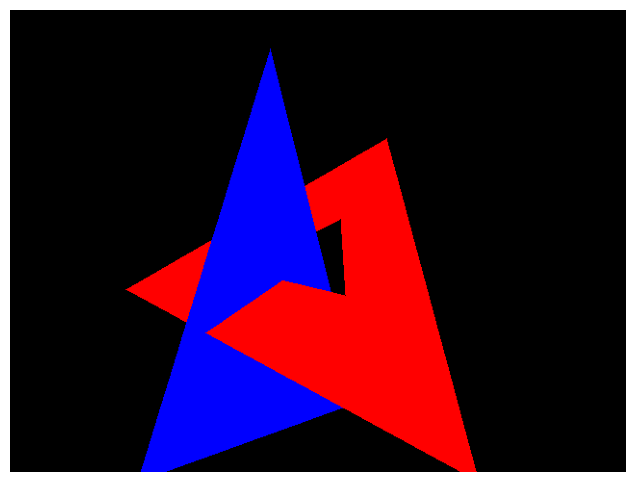

In [ ]:
def project_triangle(triangle_3d, focal):
    # Projektuje 3D -> 2D (perspektywa) dla trzech wierzchołków trójkąta
    triangle_h = np.hstack((triangle_3d, np.ones((3, 1), dtype=float)))
    projected_h = (Persp(focal) @ triangle_h.T).T
    w = np.where(np.abs(projected_h[:, 3]) < 1e-12, 1e-12, projected_h[:, 3])
    return np.column_stack((projected_h[:, 0] / w, projected_h[:, 1] / w))


def triangle_normal(triangle_3d):
    # Oblicza wektor normalny trójkąta (z użyciem iloczynu wektorowego)
    v0, v1, v2 = triangle_3d
    return np.cross(v1 - v0, v2 - v0)


def triangle_color(triangle_3d, front_color, back_color):
    # Wybiera kolor w zależności od tego którą stroną trójkąt zwrócony jest do kamery
    normal = triangle_normal(triangle_3d)
    centroid = triangle_3d.mean(axis=0)
    camera = np.array([0.0, 0.0, f], dtype=float)
    view_vector = camera - centroid
    return front_color if np.dot(normal, view_vector) >= 0.0 else back_color


def fit_z_plane(proj_xy, tri_3d):
    # Dopasowuje parametry płaszczyzny z = a*x + b*y + c korzystając z trzech punktów
    M = np.column_stack((proj_xy[:, 0], proj_xy[:, 1], np.ones(3)))
    z = tri_3d[:, 2]
    a, b, c = np.linalg.solve(M, z)
    return a, b, c


# funkcja zwracająca współczynniki prostej przechodzącej przez a->b
# orientuje je tak aby reference_point dał wartość >= 0
def line_coeff(a, b, reference_point):
    A = a[1] - b[1]
    B = b[0] - a[0]
    C = a[0] * b[1] - b[0] * a[1]
    # jeśli reference point daje ujemną wartość, odwróć orientację
    val = A * reference_point[0] + B * reference_point[1] + C
    if val < 0:
        A, B, C = -A, -B, -C
    return A, B, C


# PARAMETRY
rozdzielczosc_x = 640
rozdzielczosc_y = 480
DX = 0.01
DY = 0.01
f = 5.0

A = np.array([[2.0, 0.5, 10.0], [-1.0, -1.5, 12.0], [-1.0, 1.5, 8.0]], dtype=float)
A_hole = np.array(
    [[0.8, 0.3, 10.0], [-0.25, -0.25, 10.5], [-0.25, 0.5, 9.5]], dtype=float
)
B = np.array([[0.5, -2.0, 10.0], [-0.5, 2.0, 11.0], [1.5, 2.0, 9.0]], dtype=float)

# przygotuj obraz i z-buffer
image = np.zeros((rozdzielczosc_y, rozdzielczosc_x, 3), dtype=np.uint8)
zbuffer = np.full((rozdzielczosc_y, rozdzielczosc_x), np.inf, dtype=float)

# przygotuj listę trójkątów z wszystkimi potrzebnymi danymi do algorytmu z-buffer
triangles = []
for tri_3d, hole_3d, front_col, back_col in [
    (
        A,
        A_hole,
        np.array([255, 0, 0], dtype=np.uint8),
        np.array([0, 255, 0], dtype=np.uint8),
    ),
    (
        B,
        None,
        np.array([0, 0, 255], dtype=np.uint8),
        np.array([255, 255, 0], dtype=np.uint8),
    ),
]:
    # projektujemy trójkąt do współrzędnych obrazu i na piksele
    proj_xy = project_triangle(tri_3d, f)
    tri_px = np.array(
        [mat2pix(rozdzielczosc_x, rozdzielczosc_y, DX, DY, x, y) for x, y in proj_xy],
        dtype=float,
    )

    # współczynniki prostych krawędzi trójkąta (w przestrzeni pikseli)
    # są już preorientowane - opposite vertex będzie zawsze >= 0
    A0, B0, C0 = line_coeff(tri_px[0], tri_px[1], tri_px[2])
    A1, B1, C1 = line_coeff(tri_px[1], tri_px[2], tri_px[0])
    A2, B2, C2 = line_coeff(tri_px[2], tri_px[0], tri_px[1])

    # jeśli trójkąt ma dziure, przygotuj współczynniki dla dziury
    hole_lines = None
    if hole_3d is not None:
        hole_proj = project_triangle(hole_3d, f)
        hole_px = np.array(
            [
                mat2pix(rozdzielczosc_x, rozdzielczosc_y, DX, DY, x, y)
                for x, y in hole_proj
            ],
            dtype=float,
        )
        hA0, hB0, hC0 = line_coeff(hole_px[0], hole_px[1], hole_px[2])
        hA1, hB1, hC1 = line_coeff(hole_px[1], hole_px[2], hole_px[0])
        hA2, hB2, hC2 = line_coeff(hole_px[2], hole_px[0], hole_px[1])
        hole_lines = (hA0, hB0, hC0, hA1, hB1, hC1, hA2, hB2, hC2)

    # dopasuj płaszczyznę aby policzyć z dla dowolnego piksela obrazu
    a, b, c = fit_z_plane(proj_xy, tri_3d)
    color = triangle_color(tri_3d, front_col, back_col)

    # zapisujemywspółczynniki krawędzi, opcjonalne dane dziury, parametry płaszczyzny i kolor
    triangles.append(
        {
            "lines": (A0, B0, C0, A1, B1, C1, A2, B2, C2),
            "hole_lines": hole_lines,
            "a": a,
            "b": b,
            "c": c,
            "color": color,
        }
    )

# Z-BUFFER:
for j in range(rozdzielczosc_y):
    for i in range(rozdzielczosc_x):
        x_img, y_img = pix2mat(rozdzielczosc_x, rozdzielczosc_y, DX, DY, i, j)
        for tri in triangles:
            A0, B0, C0, A1, B1, C1, A2, B2, C2 = tri["lines"]
            # wartości L(p) dla p=(i,j)
            L0 = A0 * i + B0 * j + C0
            L1 = A1 * i + B1 * j + C1
            L2 = A2 * i + B2 * j + C2
            # jeśli punkt jest wewnątrz trójkąta (wszystkie >= 0, bo współczynniki są preorientowane)
            if (L0 >= 0) and (L1 >= 0) and (L2 >= 0):
                # sprawdź czy jest w dziurze - jeśli tak, pomiń
                if tri["hole_lines"] is not None:
                    hA0, hB0, hC0, hA1, hB1, hC1, hA2, hB2, hC2 = tri["hole_lines"]
                    hL0 = hA0 * i + hB0 * j + hC0
                    hL1 = hA1 * i + hB1 * j + hC1
                    hL2 = hA2 * i + hB2 * j + hC2
                    if (hL0 >= 0) and (hL1 >= 0) and (hL2 >= 0):
                        continue
                z = tri["a"] * x_img + tri["b"] * y_img + tri["c"]
                if z < zbuffer[j, i]:
                    zbuffer[j, i] = z
                    image[j, i] = tri["color"]

# wyświetl wynik
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()